# Compute the global time series

In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())

Loading packages...


/g100/home/userexternal/ekoehn00/.conda/envs/eekenv/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


## 0) define functions

In [2]:
def calc_global_stat(da, area_weights, stat, mask=None, dims=None):
    if stat == 'mean':
        da_stat = SpaceOperator.calc_spatial_mean(da, area_weights, mask=mask, dims=dims)
    elif stat == 'integral':
        da_stat = SpaceOperator.calc_spatial_integral(da, area_weights, mask=mask, dims=dims)
    return da_stat

def get_stat(varia,default=True):
    if default == True:
        if varia in ['tas','tos']:
            stat = 'mean'
        elif varia in ['fgco2','intpp','nbp','npp']:
            stat = 'integral'
    else:
        stat = 'mean'
    return stat

def convert_units(varia,stat,da):
    if varia == 'fgco2' and stat == 'integral' and da.units in ['kg m-2 s-1 x m2','kgC/m2/s x m2']:
        converter = 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'nbp' and stat == 'integral' and da.units in ['kg m-2 s-1 x m2','kgC/m2/s x m2']:
        converter = 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'intpp' and stat == 'integral' and da.units in ['mol m-2 s-1 x m2','mol/m2/s x m2']:
        converter = 12 * 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'npp' and stat == 'integral' and da.units in ['kg m-2 s-1 x m2','kg/m2/s x m2']:
        converter = 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    else:
        da_conv = da
    return da_conv


## 1) get the varias, models and runs over which to do computation

In [3]:
#stat = 'integral'#'mean'
freq_input = 'monthly'#, 'yearly', 'daily'] #freq_output = 'monthly'#, 'yearly', 'daily', 'climatology', None]
varias = ['tas','nbp','npp','tos','fgco2','intpp']
models = ['EC-Earth3-ESM-1']#['UKESM1-2']#['IPSL-CM6-ESMCO2','NorESM2-LM','GFDL-ESM2M'] # ,'GISSE2.1-G-CC2'
runs = pruns.get_run_list('tipmip_tier1')#[-1:] #

outroot = './../01_postprocessed_data/global_time_series'

## 2) loop over models and runs to do the computation, plotting and saving

In [ ]:
for varia in varias:
    stat = get_stat(varia,default=True)
    for model in models:
        mgrab = MODELgrabber.get_grabber(model)
        member = mgrab.get_member()
        
        global_stats = dict()
        for run in runs:
            print(f'Processing data for {varia}, {model}, {run}...')
            
            # first get the dataset
            da = mgrab.get_data(varia,run,freq_input=freq_input,verbose_level=1)
            print(f'... loading {da.time.size} data points in time.')
            
            # get the area_weights
            print(f'... getting area weights.')
            area_weights = mgrab.get_area(varia,freq_input)

            #print(da)
            #print(area_weights)
            
            # which region do i want to cover
            #print(f'... getting a regional mask.') 
            
            # then do the spatial statistic
            print(f'... compute statistic')
            global_stat = calc_global_stat(da, area_weights, stat, mask=None, dims=None)#.astype("float32")
            global_stat.name = f"{varia}_global_{stat}"

            # update the unit
            if stat == 'integral':
                unit = f'{da.units} x m2'
            else:
                unit = da.units
            global_stat.attrs["units"] = unit

            # save the data
            save_dir = f'{outroot}/{varia}/{model}/{run}/{member}/{freq_input}/global_{stat}'
            os.makedirs(save_dir,exist_ok=True)
            save_string = f'{save_dir}/{varia}_{model}_{run}_{member}_global_{stat}.nc'
            print(f'... saving under {save_string}')

            #encoding = {global_stat.name: {"dtype": "float32", "zlib": True, "complevel": 4}}
            global_stat.to_netcdf(save_string)#,encoding=encoding)

            # keep in a local dictionary for plotting
            global_stats[run] = global_stat

            #for key in global_stats.keys():
            print(f'... plotting {run}')
            global_stats[run].plot()
            print(' ')

        plt.show()


## 3) Plot the time series

... plotting esm-piControl ...
... plotting esm-up2p0 ...
... plotting esm-up2p0-gwl2p0 ...
... plotting esm-up2p0-gwl4p0 ...
... plotting esm-up2p0-gwl2p0-50y-dn2p0 ...
... plotting esm-up2p0-gwl4p0-50y-dn2p0 ...
... plotting esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0 ...


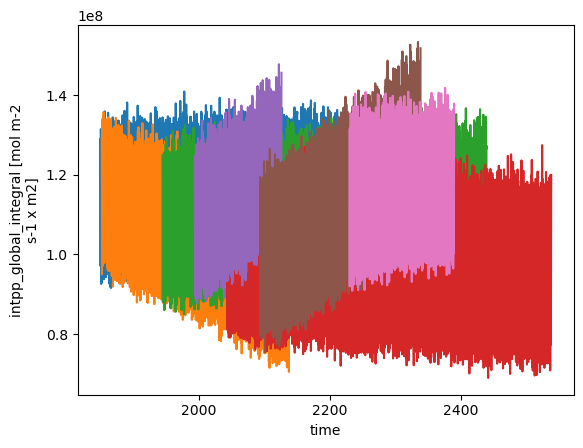

In [5]:
for key in global_stats.keys():
    print(f'... plotting {key} ...')
    global_stats[key].plot()
plt.show()